In [1]:
def fit(self, x, y):
    x_transformed = x
    for name, estimator in self.steps[:-1]:
        # iterate over all but the final step
        # fit and transform the data
        x_transformed = estimator.fit_transform(x_transformed, y)
    # fit the last step
    self.steps[-1][1].fit(x_transformed, y)
    return self

In [2]:
def predict(self, x):
    x_transformed = x
    for step in self.steps[:-1]:
        # iterate over all but the final step
        # transform the data
        x_transformed = step[1].transform(x_transformed)
    # fit the last step
    return self.steps[-1][1].predict(x_transformed)

## Convenient Pipeline Creation with make_pipline

In [2]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

svm = SVC()
# standard syntax
pipe_long = Pipeline([('scaler', MinMaxScaler()), ('svm', SVC(C=100))])

# abbreviated syntax
pipe_short = make_pipeline(MinMaxScaler(), SVC(C=100))

In [8]:
print('Pipeline steps:\n{}'.format(pipe_short.steps))

Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
print('Pipeline steps:\n{}'.format(pipe.steps))

Pipeline steps:
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


## Accesing Step Attributes

In [12]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# fit the pipeline defined before to the cancer dataset
pipe.fit(cancer.data)

# extract the first two principal components from the "pca" step
components = pipe.named_steps['pca'].components_
print('components.shape: {}'.format(components.shape))

ValueError: This LogisticRegression estimator requires y to be passed, but the target y is None.

## Accesing Attributes in a Grid-Searched Pipeline

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

pipe = make_pipeline(StandardScaler(), LogisticRegression())
param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}

x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=4)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]})

In [21]:
print('best estimator:\n{}'.format(grid.best_estimator_))

best estimator:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1))])


In [22]:
print('Logistic regression step:\n{}'.format(
    grid.best_estimator_.named_steps['logisticregression']))


Logistic regression step:
LogisticRegression(C=1)


In [23]:
print('Logistic regression coefficients:\n{}'.format(
    grid.best_estimator_.named_steps['logisticregression'].coef_))

Logistic regression coefficients:
[[-0.43570655 -0.34266946 -0.40809443 -0.5344574  -0.14971847  0.61034122
  -0.72634347 -0.78538827  0.03886087  0.27497198 -1.29780109  0.04926005
  -0.67336941 -0.93447426 -0.13939555  0.45032641 -0.13009864 -0.10144273
   0.43432027  0.71596578 -1.09068862 -1.09463976 -0.85183755 -1.06406198
  -0.74316099  0.07252425 -0.82323903 -0.65321239 -0.64379499 -0.42026013]]


## Grid-Searching Preprocessing Steps and Model Parameters

In [29]:
from sklearn.datasets import fetch_california_housing
boston = fetch_california_housing()
x_train, x_test, y_train, y_test = train_test_split(boston.data, boston.target,
                                                   random_state=0)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
pipe = make_pipeline(
StandardScaler(),
PolynomialFeatures(),
Ridge())

In [31]:
param_grid = {'polynomialfeatures__degree': [1, 2, 3],
             'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

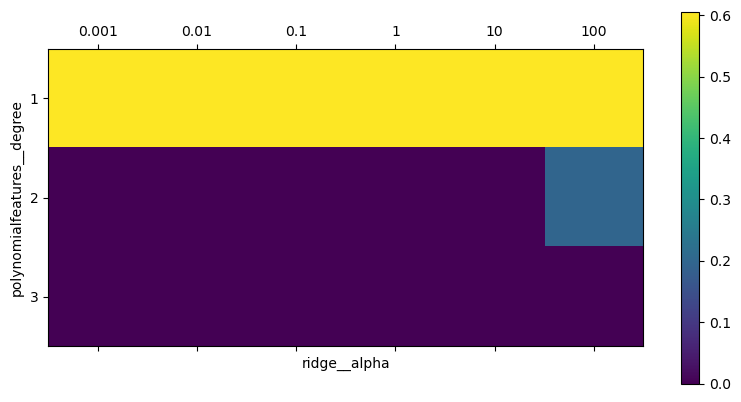

In [35]:
import matplotlib.pyplot as plt

plt.matshow(grid.cv_results_['mean_test_score'].reshape(3, -1),
            vmin=0, cmap='viridis')
plt.xlabel('ridge__alpha')
plt.ylabel('polynomialfeatures__degree')
plt.xticks(range(len(param_grid['ridge__alpha'])), param_grid['ridge__alpha'])
plt.yticks(range(len(param_grid['polynomialfeatures__degree'])), param_grid['polynomialfeatures__degree'])
plt.colorbar()

In [36]:
print('Best parameters: {}'.format(grid.best_params_))

Best parameters: {'polynomialfeatures__degree': 1, 'ridge__alpha': 10}


In [37]:
print('test-set score: {:.2f}'.format(grid.score(x_test, y_test)))

test-set score: 0.59


In [38]:
param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
pipe = make_pipeline(StandardScaler(), Ridge())
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)
print('Score without poly features: {:.2f}'.format(grid.score(x_test, y_test)))

Score without poly features: 0.59


## Grid-Searching Which Model To Use

In [6]:
pipe = Pipeline([('preprocessing', StandardScaler()), ('classifier', SVC())])

In [8]:
from sklearn.ensemble import RandomForestClassifier

param_grid = [
    {'classifier': [SVC()], 'preprocessing': [StandardScaler(), None],
    'classifer__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]},
    {'classifier': [RandomForestClassifier(n_estimators=100)],
    'preprocessing': [None], 'classifier__max_freatures': [1, 2, 3]}]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)

print('Best params:\n{}\n'.format(grid.best_params_))
print('best cross-validation score: {:.2f}'.format(grid.best_score_))
print('test-set score: {:.2f}'.format(grid.score(x_test, y_test)))

Best params:
{'logisticregression__C': 1}

best cross-validation score: 0.98
test-set score: 0.96


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_